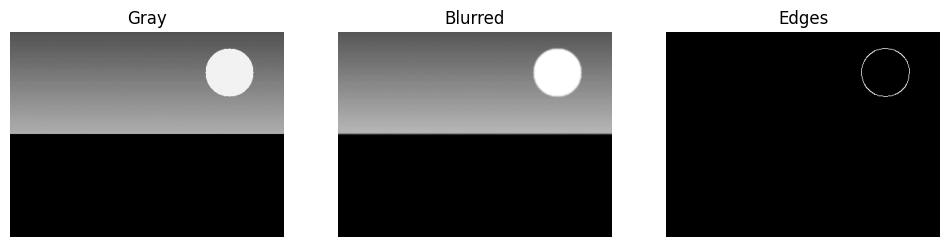

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((300, 400, 3), dtype=np.uint8)

for row in range(150):
    shade = int(180 + row * 0.4)
    img[row, :] = (shade, shade - 30, 100)
img[150:300, :] = (60, 130, 60)
cv2.circle(img, (320, 60), 35, (60, 220, 250), -1)
cv2.imwrite('sample.jpg', img)

img = cv2.imread('sample.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 100, 200)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [gray, blurred, edges], ['Gray', 'Blurred', 'Edges']):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.show()

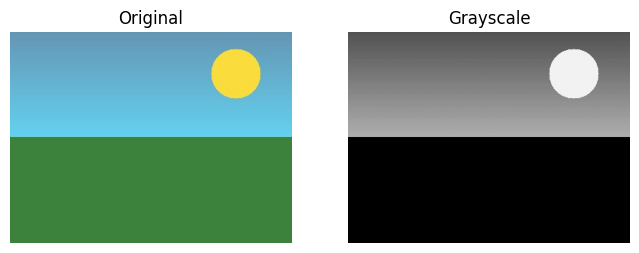

In [ ]:
img = cv2.imread('sample.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Grayscale'); axes[1].axis("off")
plt.show()

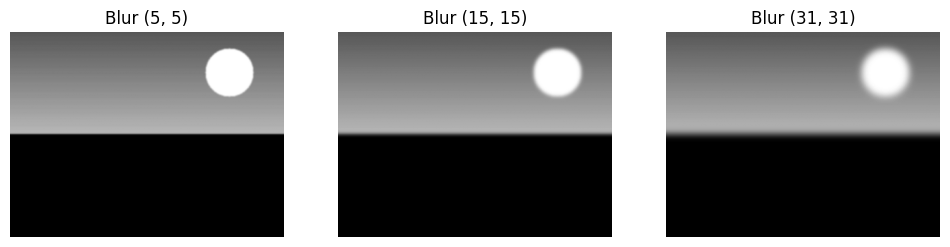

Bigger Kernel = more agressive smoothing -- (31,31) loses almost all fine details
While (5,5) only softens the sharpest edges slightly


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [(5, 5), (15, 15), (31, 31)]):
    b = cv2.GaussianBlur(gray, k, 0)
    ax.imshow(b, cmap='gray'); ax.set_title(f'Blur {k}'); ax.axis('off')

plt.show()
print('Bigger Kernel = more agressive smoothing -- (31,31) loses almost all fine details')
print('While (5,5) only softens the sharpest edges slightly')

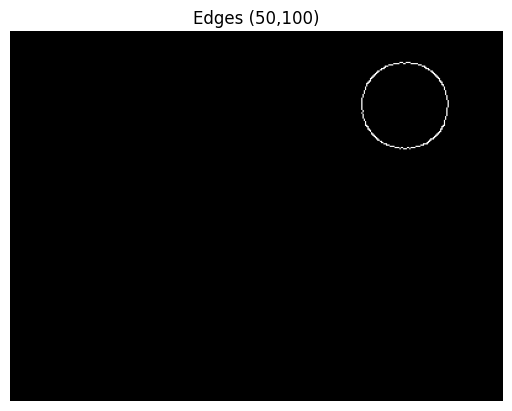

In [ ]:
blurred = cv2.GaussianBlur(gray, (15, 15), 0)
edges = cv2.Canny(blurred, 50, 100)
plt.imshow(edges, cmap='gray'); plt.axis('off'); plt.title('Edges (50,100)')
plt.show()

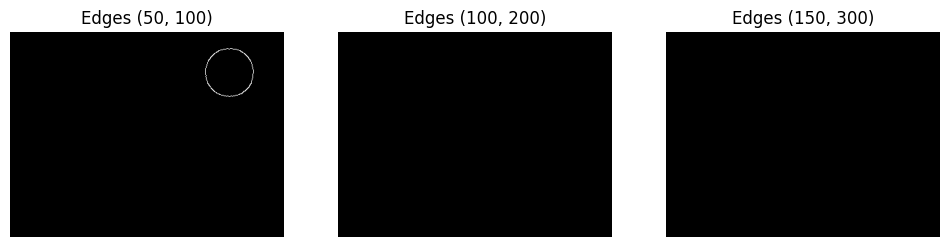

Lower thresholds (50,100) = more edges detected, including weak/noisy ones
Higher thresholds (150,300) = only strong, high-contrast edges survive


In [ ]:
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, t in zip(axes, [(50, 100), (100, 200), (150, 300)]):
    e = cv2.Canny(blurred, t[0], t[1])
    ax.imshow(e, cmap='gray'); ax.set_title(f'Edges {t}'); ax.axis('off')

plt.show()
print('Lower thresholds (50,100) = more edges detected, including weak/noisy ones')
print('Higher thresholds (150,300) = only strong, high-contrast edges survive')

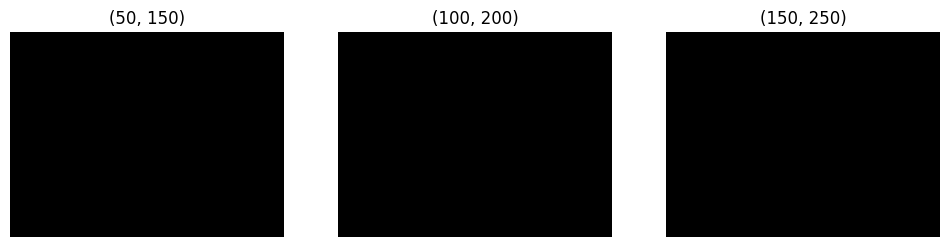

Lower threshold has more (sometimes noisy) edges; higher thresholds are stricter
and only keep the strongest, most obvious boundaries. Pick whichever pair looks
cleanest on your specific photo -- there's no universal best pair


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, (t1, t2) in zip(axes, [(50, 150), (100, 200), (150, 250)]):
    e = cv2.Canny(blurred, t1, t2)
    ax.imshow(e, cmap='gray'); ax.set_title(f'({t1}, {t2})'); ax.axis('off')
plt.show()

print("Lower threshold has more (sometimes noisy) edges; higher thresholds are stricter")
print("and only keep the strongest, most obvious boundaries. Pick whichever pair looks")
print("cleanest on your specific photo -- there's no universal best pair")

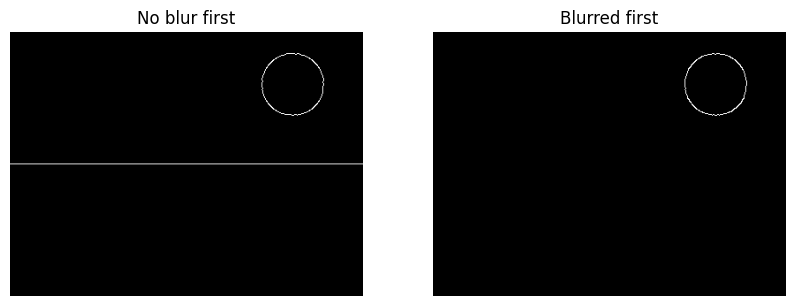

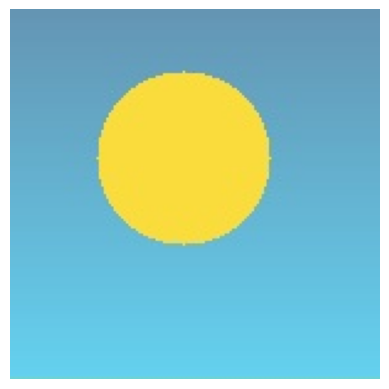

In [ ]:
edges_noblur = cv2.Canny(gray, 50, 100)
edges_blurred = cv2.Canny(blurred, 50, 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(edges_noblur, cmap='gray'); axes[0].set_title('No blur first'); axes[0].axis('off')
axes[1].imshow(edges_blurred, cmap='gray'); axes[1].set_title('Blurred first'); axes[1].axis('off')
plt.show()

crop = img[0:150, 250:400]
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()